In [ ]:
import pandas as pd

df = pd.read_excel("../data/Dataset.xlsx")

df.head()



Rows: 100
Columns: 10


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

In [3]:
df.columns.tolist()

['Date',
 'URL',
 'Source Name',
 'Title',
 'Opening Text',
 'Hit Sentence',
 'Driver',
 'Sub driver',
 'Sentiment',
 'Reach']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          84 non-null     datetime64[us]
 1   URL           100 non-null    str           
 2   Source Name   91 non-null     str           
 3   Title         81 non-null     str           
 4   Opening Text  95 non-null     str           
 5   Hit Sentence  54 non-null     str           
 6   Driver        0 non-null      float64       
 7   Sub driver    0 non-null      float64       
 8   Sentiment     100 non-null    str           
 9   Reach         65 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(6)
memory usage: 7.9 KB


In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Date             16
Source Name       9
Title            19
Opening Text      5
Hit Sentence     46
Driver          100
Sub driver      100
Reach            35
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df["Title"].duplicated().sum()

np.int64(24)

In [12]:
df["URL"].duplicated().sum()

np.int64(15)

In [13]:
df["Sentiment"].value_counts()

Sentiment
neutral     52
positive    33
Negative    12
Positive     3
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


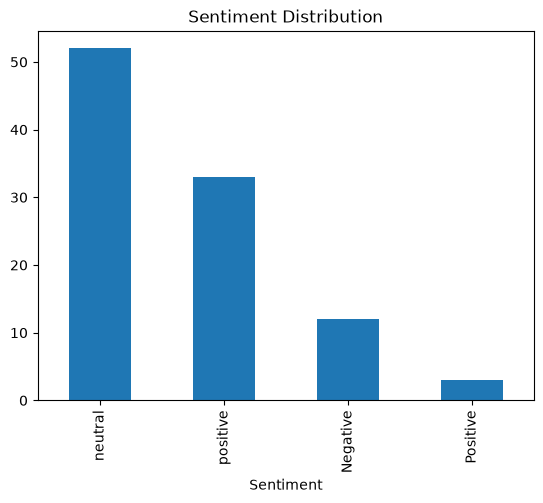

In [14]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.show()

In [15]:
df.sample(10)

,Date,URL,Source Name,Title,Opening Text,Hit Sentence,Driver,Sub driver,Sentiment,Reach
38,2025-11-08,https://www.reddit.com/r/MutualfundsIndia/comm...,reddit.com/r/MutualfundsIndia,NaN,NaN,hanks for the suggestion! I’ll definitely chec...,NaN,NaN,neutral,10617726.0
50,2025-08-05,https://www.zeebiz.com/personal-finance/mutual...,Zee Business,Top 7 largecap mutual funds; know how much ret...,The seventh fund on the list is Baroda BNP Par...,NaN,NaN,NaN,neutral,58845.0
61,2025-07-23,https://www.angelone.in/news/best-gold-etfs-in...,Angel One,Best Gold ETFs in India in August 2025 Based o...,"ICICI Prudential, HDFC, SBI, Kotak, and Nippon...",NaN,NaN,NaN,neutral,16655916.0
80,2025-08-17,https://www.reddit.com/r/mutualfunds/comments/...,reddit.com/r/mutualfunds,Questions regarding ICICI Prudential Mutual Fu...,have watched this interview.\n\nS Naren is a ...,nvesting in the Current Stock Market: Strategi...,NaN,NaN,neutral,NaN
87,2025-07-15,https://www.reddit.com/r/MutualfundsIndia/comm...,reddit.com/r/MutualfundsIndia,NaN,NaN,Icici prudential multi asset fund\n\nThis alon...,NaN,NaN,neutral,246890.0
24,2025-09-30,https://www.businesstoday.in/personal-finance/...,Business Today,ICICI Prudential MF launches conglomerate-focu...,ICICI Prudential Conglomerate Fund’s investmen...,"... Naren, executive director and chief invest...",NaN,NaN,neutral,33585792.0
26,NaT,https://play.google.com/store/apps/details?id=...,Play Store,Digital Experience,Absolutely love the new logo design.It's now v...,NaN,NaN,NaN,Positive,NaN
74,2025-07-10,https://www.cnbctv18.com/personal-finance/icic...,CNBC-TV18,Why ICICI Pru MF’s Chintan Haria believes it’s...,Haria explains that when markets turn cautious...,"... now. Chintan Haria, Principal – Investment...",NaN,NaN,positive,11569309.0
4,2025-07-01,https://economictimes.indiatimes.com/mf/mf-new...,The Economic Times,NFO Update: ICICI Prudential Mutual Fund launc...,ICICI Prudential launches a Nifty Private Bank...,"... , and long-term potential in banking. ICIC...",NaN,NaN,positive,62646070.0
30,2025-08-22,https://economictimes.indiatimes.com/mf/analys...,The Economic Times,35 equity mutual funds complete over 25 years ...,"As numerous new schemes emerge, 35 equity mutu...",NaN,NaN,NaN,neutral,12220656.0


In [16]:
df["combined_text"] = (
    df["Title"].fillna("") +
    " " +
    df["Opening Text"].fillna("") +
    " " +
    df["Hit Sentence"].fillna("")
)

In [17]:
df["combined_text"].head()

0    ICICI Prudential Mutual Fund Launches Two Offe...
1    Best Fund Managers 2025: Top wealth creators w...
2    A hybrid mutual fund has turned ₹1,000 monthly...
3    How to invest for a balanced portfolio this Di...
4    NFO Update: ICICI Prudential Mutual Fund launc...
Name: combined_text, dtype: str

In [18]:
df["text_length"] = df["combined_text"].str.len()

df["text_length"].describe()

count     100.000000
mean      490.100000
std      1114.113422
min        55.000000
25%       229.500000
50%       341.000000
75%       381.250000
max      8133.000000
Name: text_length, dtype: float64

In [19]:
report = {
    "Total Records": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum().to_dict(),
    "Duplicate Rows": int(df.duplicated().sum())
}

print(report)

{'Total Records': 100, 'Total Columns': 12, 'Missing Values': {'Date': 16, 'URL': 0, 'Source Name': 9, 'Title': 19, 'Opening Text': 5, 'Hit Sentence': 46, 'Driver': 100, 'Sub driver': 100, 'Sentiment': 0, 'Reach': 35, 'combined_text': 0, 'text_length': 0}, 'Duplicate Rows': 1}


In [20]:
with open("../output/data_summary.txt","w") as f:
    f.write(str(report))